Task 2

In [1]:
import torch
import torch.nn as nn

latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, 28, 28)

G = Generator()
print(G)
print("Trainable params:", sum(p.numel() for p in G.parameters() if p.requires_grad))

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)
Trainable params: 559632


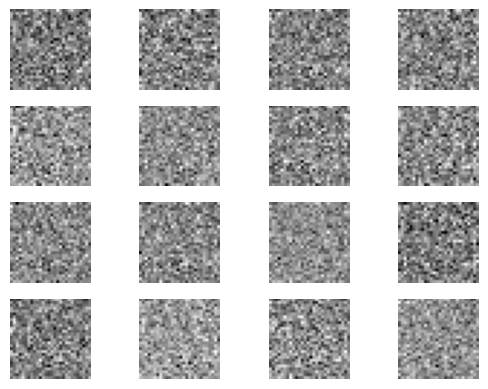

In [2]:
z = torch.randn(16, latent_dim)
fake_imgs = G(z).detach()

import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4)
for i in range(16):
    axs[i//4, i%4].imshow(fake_imgs[i].squeeze(), cmap='gray')
    axs[i//4, i%4].axis('off')
plt.show()

Task 3

In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

D = Discriminator()
print(D)
print("Trainable params:", sum(p.numel() for p in D.parameters() if p.requires_grad))

Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)
Trainable params: 533505


In [4]:
real_sample = torch.randn(16, 1, 28, 28)
fake_sample = G(torch.randn(16, latent_dim)).detach()

print("Real scores:", D(real_sample))
print("Fake scores:", D(fake_sample))

Real scores: tensor([[0.5114],
        [0.4998],
        [0.4836],
        [0.4807],
        [0.4787],
        [0.4671],
        [0.4527],
        [0.5127],
        [0.4793],
        [0.4967],
        [0.5164],
        [0.5043],
        [0.4956],
        [0.4727],
        [0.4679],
        [0.4764]], grad_fn=<SigmoidBackward0>)
Fake scores: tensor([[0.5019],
        [0.5009],
        [0.5010],
        [0.5010],
        [0.5005],
        [0.5027],
        [0.5033],
        [0.5026],
        [0.5047],
        [0.5002],
        [0.5010],
        [0.5015],
        [0.5027],
        [0.4984],
        [0.5007],
        [0.5029]], grad_fn=<SigmoidBackward0>)


Task 4

In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.MNIST(
    root="C:\\Users\\alias\\Downloads\\Lab9_dataset",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:11<00:00, 864kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 567kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 246kB/s]


In [10]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

epochs = 20

G_losses = []
D_losses = []

for epoch in range(epochs):
    for imgs, _ in dataloader:

        batch_size = imgs.size(0)
        real = torch.ones(batch_size, 1)
        fake = torch.zeros(batch_size, 1)

        z = torch.randn(batch_size, latent_dim)
        fake_imgs = G(z)

        loss_real = criterion(D(imgs), real)
        loss_fake = criterion(D(fake_imgs.detach()), fake)
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        loss_G = criterion(D(fake_imgs), real)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    print(f"Epoch {epoch}: D={loss_D.item():.4f}, G={loss_G.item():.4f}")

Epoch 0: D=0.1842, G=4.2172
Epoch 1: D=1.0803, G=2.2317
Epoch 2: D=0.0854, G=3.7236
Epoch 3: D=0.1812, G=5.0118
Epoch 4: D=0.2040, G=5.4255
Epoch 5: D=0.0403, G=7.6161
Epoch 6: D=0.2417, G=5.0824
Epoch 7: D=0.2782, G=3.8247
Epoch 8: D=0.1787, G=4.1656
Epoch 9: D=0.4683, G=6.4848
Epoch 10: D=0.2361, G=3.4837
Epoch 11: D=0.4029, G=3.6052
Epoch 12: D=0.3156, G=4.9364
Epoch 13: D=0.2938, G=4.9393
Epoch 14: D=0.5943, G=3.9782
Epoch 15: D=0.6999, G=2.3123
Epoch 16: D=0.3584, G=2.7088
Epoch 17: D=0.3472, G=2.5482
Epoch 18: D=0.6083, G=3.0983
Epoch 19: D=0.6534, G=2.2431


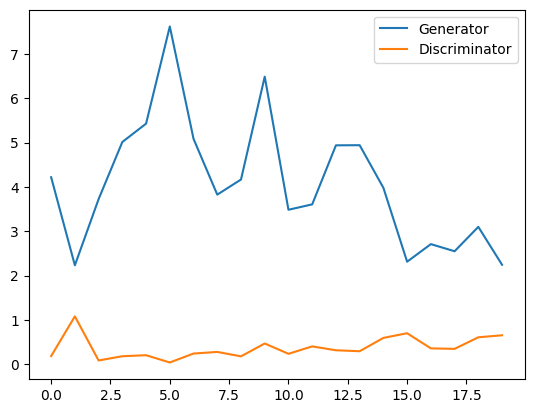

In [11]:
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.legend()
plt.show()

Task 5

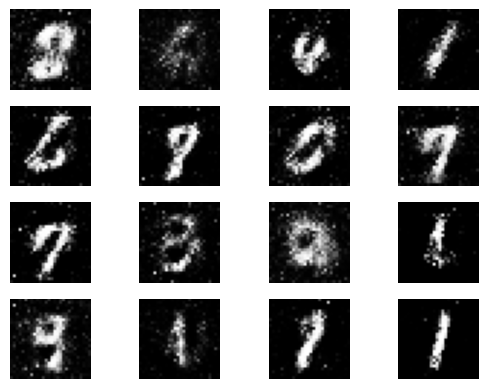

In [12]:
z = torch.randn(16, latent_dim)
gen_imgs = G(z).detach()

fig, axs = plt.subplots(4, 4)
for i in range(16):
    axs[i//4, i%4].imshow(gen_imgs[i].squeeze(), cmap='gray')
    axs[i//4, i%4].axis('off')
plt.show()

Task 6

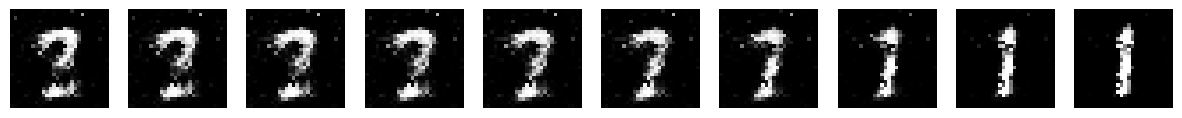

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

z1 = torch.randn(1, latent_dim)
z2 = torch.randn(1, latent_dim)

steps = 10

interpolated_imgs = []

for alpha in np.linspace(0, 1, steps):
    z = (1 - alpha) * z1 + alpha * z2
    img = G(z).detach()
    interpolated_imgs.append(img)

fig, axs = plt.subplots(1, steps, figsize=(15, 2))

for i in range(steps):
    axs[i].imshow(interpolated_imgs[i].squeeze(), cmap='gray')
    axs[i].axis('off')

plt.show()

Task 7

In [18]:
z = torch.randn(100, latent_dim)
gen_imgs = G(z).detach()

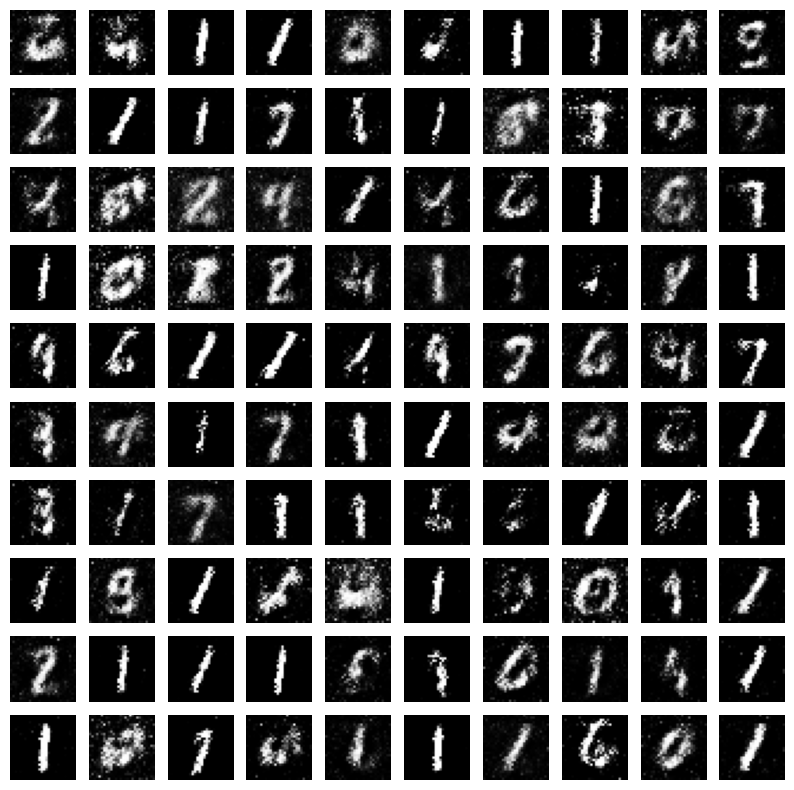

In [19]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10))

for i in range(100):
    axs[i//10, i%10].imshow(gen_imgs[i].squeeze(), cmap='gray')
    axs[i//10, i%10].axis('off')

plt.show()

Task 8

In [20]:
real = torch.full((batch_size, 1), 0.9)
fake = torch.zeros(batch_size, 1)

In [21]:
fake = torch.full((batch_size, 1), 0.1)

Task 9

In [22]:
real_pixels = []

for imgs, _ in dataloader:
    real_pixels.append(imgs.view(-1).numpy())
    break

real_pixels = real_pixels[0]

In [23]:
z = torch.randn(64, latent_dim)
fake_imgs = G(z).detach()

fake_pixels = fake_imgs.view(-1).numpy()

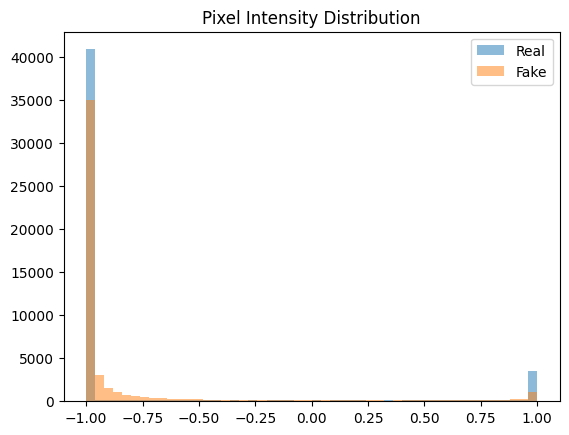

In [24]:
import matplotlib.pyplot as plt

plt.hist(real_pixels, bins=50, alpha=0.5, label='Real')
plt.hist(fake_pixels, bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.title("Pixel Intensity Distribution")
plt.show()